# L2C nonlinear ODE via Differentiable Predictive Control

This tutorial demonstrates the use of [Differentiable predictive control (DPC) method](https://www.sciencedirect.com/science/article/pii/S0959152422000981) to learn parametric neural control policy for reference tracking of nonlinear ordinary differential equations (ODE).

The implementation is using the [Neuromancer](https://github.com/pnnl/neuromancer) library.
Example adopted from [APMonitor](https://apmonitor.com/do/index.php/Main/LevelControl).

**Schematics of the Differentiable Predictive Control method**:
<img src="./DPC_simple_method.png" width="600">

### References

[1] [Drgona, Jan, et al. "Differentiable Predictive Control: An MPC Alternative for Unknown Nonlinear Systems using Constrained Deep Learning." Journal of Process Control, 2022](https://www.sciencedirect.com/science/article/pii/S0959152422000981)

[2] [Jan Drgona and Aaron Tuor and Draguna Vrabie, Learning Constrained  Parametric Differentiable Predictive Control Policies With Guarantees, IEEE TSMC: Systems, 2024](https://ieeexplore.ieee.org/abstract/document/10479163/)

[3] [Neuromancer SciML library](https://github.com/pnnl/neuromancer)

[4] [APMonitor MPC example](https://apmonitor.com/do/index.php/Main/LevelControl)

## NeuroMANCER and Dependencies

### Install (Colab only)
Skip this step when running locally.

In [98]:
!pip install neuromancer

*Note: When running on Colab, one might encounter a pip dependency error with Lida 0.0.10. This can be ignored*

In [99]:
import torch
import torch.nn as nn
import numpy as np

import neuromancer.psl as psl
from neuromancer.system import Node, System, SystemPreview
from neuromancer.modules import blocks
from neuromancer.modules.activations import activations
from neuromancer.dataset import DictDataset
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem
from neuromancer.trainer import Trainer
from neuromancer.dynamics import ode, integrators
from neuromancer.plot import pltCL, pltPhase

## System model 

Lets consider the following system of two connected tanks controlled by a single pump and a two way valve.
The system is a simplified model of a [pumped-storage hydroelectricity](https://en.wikipedia.org/wiki/Pumped-storage_hydroelectricity) which is a type of hydroelectric energy storage used by electric power systems for [load balancing](https://en.wikipedia.org/wiki/Load_balancing_(electrical_power). 

**System schematics**:  
<img src="./two_tank_level.png" width="250">

**System model**:  
The system dynamics is defined by following nonlinear ordinary differential equations (ODEs):
$$
 \frac{dx_1}{dt} = c_1 (1.0 - v)  p - c_2  \sqrt{x_1}  \\  
 \frac{dx_2}{dt}  = c_1 v p + c_2  \sqrt{x_1} - c_2 \sqrt{x_2}
$$  
With system states $x_1$, and $x_2$ representing liquid levels in tank 1 and 2, respectively. Control actions are pump modulation $p$, and valve opening $v$. The ODE system is parametrized by inlet and outlet valve coefficients $c_1$ and $c_2$, respectively.

**Control ojective**:   
The objective is to control the tank levels into desired reference values by modulating the pump and valve control actions.

System model and image adopted from: https://apmonitor.com/do/index.php/Main/LevelControl

In [100]:
#define problem dimensions

# problem dimensions
nx = 2    # number of states
nu = 2    # number of control inputs
nref = 2           # number of references
# constraints bounds
umin = 0
umax = 1.
xmin = 0
xmax = 1.

## Training dataset generation

For a training dataset we randomly sample initial conditions of states and sequence of admissible reference trajectories over predefined prediction horizon from given distributions $\mathcal{P}_{x_0}$, and $\mathcal{P}_R$, respectively.

In [101]:
nsteps = 30  # prediction horizon
n_samples = 2000    # number of sampled scenarios

#  sampled references for training the policy
list_refs = [torch.rand(1, 1)*torch.ones(nsteps+1, nref) for k in range(n_samples)]
ref = torch.cat(list_refs)
batched_ref = ref.reshape([n_samples, nsteps+1, nref])
# Training dataset
train_data = DictDataset({'x': torch.rand(n_samples, 1, nx),   # sampled initial conditions of states
                          'r': batched_ref}, name='train')

# sampled references for development set
list_refs = [torch.rand(1, 1)*torch.ones(nsteps+1, nref) for k in range(n_samples)]
ref = torch.cat(list_refs)
batched_ref = ref.reshape([n_samples, nsteps+1, nref])
# Development dataset
dev_data = DictDataset({'x': torch.rand(n_samples, 1, nx),    # sampled initial conditions of states
                        'r': batched_ref}, name='dev')

# torch dataloaders
batch_size = 200
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
                                           collate_fn=train_data.collate_fn,
                                           shuffle=False)
dev_loader = torch.utils.data.DataLoader(dev_data, batch_size=batch_size,
                                         collate_fn=dev_data.collate_fn,
                                         shuffle=False)

Visualize the training data.

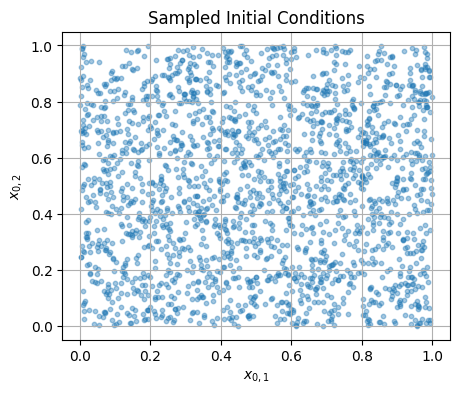

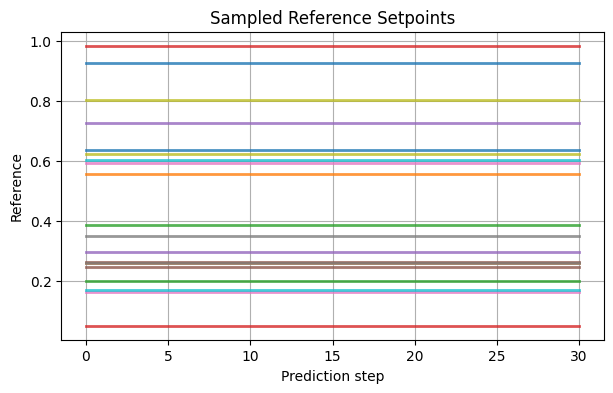

In [102]:
# ------------------------------------------------------------
# Visualize sampled initial conditions and reference trajectories
# ------------------------------------------------------------
import matplotlib.pyplot as plt

# Extract training samples
x0_train = train_data.datadict["x"][:, 0, :].detach().cpu().numpy()
r_train = train_data.datadict["r"].detach().cpu().numpy()

# Plot sampled initial conditions
plt.figure(figsize=(5, 4))

if nx == 1:
    plt.hist(x0_train[:, 0], bins=30, alpha=0.8)
    plt.xlabel(r"$x_0$")
    plt.ylabel("Count")
else:
    plt.scatter(x0_train[:, 0], x0_train[:, 1], s=10, alpha=0.4)
    plt.xlabel(r"$x_{0,1}$")
    plt.ylabel(r"$x_{0,2}$")

plt.title("Sampled Initial Conditions")
plt.grid(True)
plt.show()

n_plot = 20
t = np.arange(batched_ref.shape[1])
plt.figure(figsize=(7,4))
for i in range(n_plot):
    plt.plot(
        t,
        batched_ref[i, :, 0].cpu().numpy(),
        linewidth=2,
        alpha=0.8,
    )

plt.xlabel("Prediction step")
plt.ylabel("Reference")
plt.title("Sampled Reference Setpoints")
plt.grid(True)
plt.show()

### Neural control policy

The objective of this tutorial is to learn neural control policy $u_k = \pi(x_k, R)$ to control the tank levels by modulating the pump and valve control actions $u_k = [p_k, v_k]$. The policy takes in the measurements of system states $x_k$ at thime $k$ and desired references $R = [r_k, ..., r_{k+N}]$ over pre-defined horizon $N$. This tutorial shows how to construct a simple DPC policy without reference preview, i.e., $R=r_k$. For more advanced examples, including full reference preview see the Neuromancer library.


We instantiate a simple multi-layer perceptron (MLP) policy as the learned control solution map. Given the current state $x_k$ and reference $r_k$, the unconstrained policy output is

$
\tilde u_k = \pi_\theta(x_k,r_k).
$

Hard input bounds are enforced by a closed-form projection onto the admissible box constraint

$
\mathcal U = \{u \mid u_{\min} \le u \le u_{\max}\}.
$

Thus, the applied control action is

$
u_k
=
\Pi_{\mathcal U}(\tilde u_k)
=
\min\!\left(
u_{\max},
\max\!\left(
u_{\min},
\pi_\theta(x_k,r_k)
\right)
\right).
$

This projection layer is differentiable almost everywhere and can be included directly in the DPC computational graph.

In [111]:
# neural net control policy with hard control action bounds
net = blocks.MLP_bounds(insize=nx + nref, outsize=nu, hsizes=[32, 32],
                    nonlin=activations['gelu'], min=umin, max=umax)

### Differentiable ODE system model

The DPC is a model-based policy optimization algorithm, that exploits the differentiability of a wide class of model representations for dynamical systems, including differential equations, state-space models, or various neural network architectures. In this example, we compactly represent the system model by ODE equations  $\text{ODESolve}(f(x^i_k, u^i_k))$  describing the governing dynamics of the controlled system.

In the following, we instatiate a continous-time system model together with a 4th order Ruge-Kutta numerical integrator.

In [104]:
# white-box ODE model with no-plant model mismatch
two_tank_ode = ode.TwoTankParam()                   # ODE system equations implemented in PyTorch
two_tank_ode.c1 = nn.Parameter(torch.tensor(0.08), requires_grad=False)
two_tank_ode.c2 = nn.Parameter(torch.tensor(0.04), requires_grad=False)
# step size
ts = 1.0

# integrate continuous time ODE
integrator = integrators.RK4(two_tank_ode, h=torch.tensor(ts))   # using 4th order runge kutta integrator

### Differentiable closed-loop system in Neuromancer

Here we construct a closed-loop systems as differentiable computational graphs by connecting the system dynamics model  $x_{k+1} = \text{ODESolve}(f(x_k, u_k))$ with neural control policy $\pi_\theta(x_k, r_k) : \mathbb{R}^{n_x\times n_r} \mapsto \mathbb{R}^{n_u}$. Hence, we obtain a trainable closed-loop system  $x_{k+1} = \text{ODESolve}(f(x_k, \pi_{\theta}(x_k, r_k)))$,


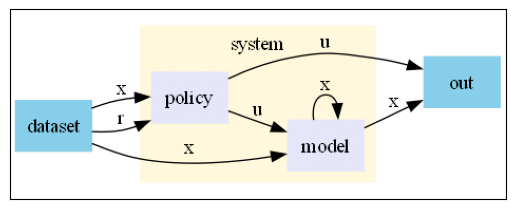

In [105]:
# symbolic system model
model = Node(integrator, ['x', 'u'], ['x'], name='model')

# symbolic neural control policy
policy = Node(net, ['x', 'r'], ['u'], name='policy')

# closed-loop system model
cl_system = System([policy, model], nsteps=nsteps)
cl_system.show()

### Differentiable Predictive Control objectives and constraints

Here we take advantage of Neuromancer's high level symbolic language to define objective and constraint terms of our optimal control problem. Furthermore, we utilize a penalty method for constraint relaxation.

In [106]:
# variables
x = variable('x')
ref = variable("r")
# objectives
regulation_loss = 5. * ((x == ref) ^ 2)  # target posistion
# constraints
state_lower_bound_penalty = 10.*(x > xmin)
state_upper_bound_penalty = 10.*(x < xmax)
terminal_lower_bound_penalty = 10.*(x[:, [-1], :] > ref-0.01)
terminal_upper_bound_penalty = 10.*(x[:, [-1], :] < ref+0.01)
# objectives and constraints names for nicer plot
regulation_loss.name = 'state_loss'
state_lower_bound_penalty.name = 'x_min'
state_upper_bound_penalty.name = 'x_max'
terminal_lower_bound_penalty.name = 'y_N_min'
terminal_upper_bound_penalty.name = 'y_N_max'
# list of constraints and objectives
objectives = [regulation_loss]
constraints = [
    state_lower_bound_penalty,
    state_upper_bound_penalty,
    terminal_lower_bound_penalty,
    terminal_upper_bound_penalty,
]
# create constrained optimization loss
loss = PenaltyLoss(objectives, constraints)

### Solving the parametric optimal control problem

Here we put everything together to construct a differentiable optimal control problem. Specifically, we learn an explicit neural control policy by solving the following parametric optimal control problem:

$$
\begin{aligned}
\underset{\theta}{\mathrm{minimize}}
\qquad
&
\sum_{i=1}^{m}
\Bigg(
\sum_{k=0}^{N-1}
Q_x\|x_k^i-r_k^i\|_2^2
+
Q_c\,p_x(x_k^i)
+
Q_N\|x_N^i-r_N^i\|_2^2
\Bigg)
\\
\mathrm{subject\ to}
\qquad
&
x_{k+1}^i
=
\mathrm{ODESolve}\!\left(
f(x_k^i,u_k^i)
\right),
\\
&
u_k^i
=
\Pi_{\mathcal U}
\!\left(
\pi_\theta(x_k^i,R^i)
\right),
\\
&
x_0^i\sim\mathcal P_{x_0},
\\
&
R^i\sim\mathcal P_R .
\end{aligned}
$$

Here, the control policy is represented by the neural network $\pi_\theta$, while the projection operator
$
\Pi_{\mathcal U}:\mathbb{R}^{n_u}\rightarrow\mathcal U
$
enforces hard box constraints on the control inputs. State constraints are incorporated as a penalty function $p_x(x)
=
\left\|
\mathrm{ReLU}
\!\left(
\begin{bmatrix}
x-x_{\max}\\
x_{\min}-x
\end{bmatrix}
\right)
\right\|_2^2,$
weighted by the coefficient $Q_c$. The objective minimizes the reference tracking error over the prediction horizon together with a terminal tracking penalty weighted by $Q_N$. Training scenarios are generated by sampling initial conditions $x_0\sim\mathcal P_{x_0}$ and reference trajectories $R\sim\mathcal P_R$. The policy parameters $\theta$ are optimized end-to-end using stochastic gradient descent through the differentiable closed-loop system.

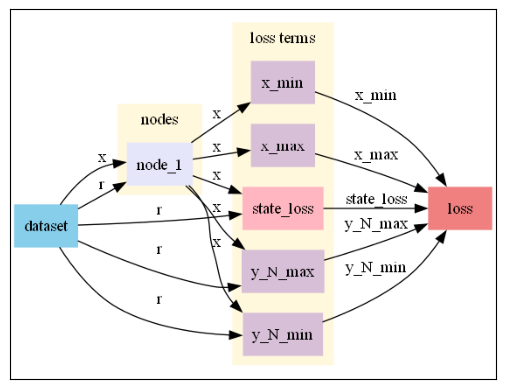

In [107]:
# construct constrained optimization problem without reference preview
# data (x_k, r_k) -> parameters (xi_k) -> policy (u_k) -> dynamics (x_{k+1})
problem = Problem([cl_system], loss)
# plot computational graph
problem.show()

We solve the problems using stochastic gradient descent over training data of sampled parameteric scenarios.

In [108]:
optimizer = torch.optim.AdamW(problem.parameters(), lr=0.003)
#  Neuromancer trainer
trainer = Trainer(
    problem,
    train_loader, dev_loader,
    optimizer=optimizer,
    epochs=200,
    train_metric='train_loss',
    eval_metric='dev_loss',
    warmup=50, 
)
# Train control policy
best_model = trainer.train()
# load best trained model
trainer.model.load_state_dict(best_model)

epoch: 0  train_loss: 3.9450321197509766
epoch: 1  train_loss: 3.3443875312805176
epoch: 2  train_loss: 2.8617875576019287
epoch: 3  train_loss: 2.244568347930908
epoch: 4  train_loss: 1.60793936252594
epoch: 5  train_loss: 1.338195562362671
epoch: 6  train_loss: 1.1965386867523193
epoch: 7  train_loss: 1.0857470035552979
epoch: 8  train_loss: 1.0022834539413452
epoch: 9  train_loss: 0.9391466975212097
epoch: 10  train_loss: 0.8908276557922363
epoch: 11  train_loss: 0.8490980267524719
epoch: 12  train_loss: 0.8140376210212708
epoch: 13  train_loss: 0.7853009700775146
epoch: 14  train_loss: 0.762310802936554
epoch: 15  train_loss: 0.7442235946655273
epoch: 16  train_loss: 0.7303410768508911
epoch: 17  train_loss: 0.7194043397903442
epoch: 18  train_loss: 0.7109391093254089
epoch: 19  train_loss: 0.7038581371307373
epoch: 20  train_loss: 0.6981720924377441
epoch: 21  train_loss: 0.6930066347122192
epoch: 22  train_loss: 0.6889129281044006
epoch: 23  train_loss: 0.6864582300186157
epoch: 

<All keys matched successfully>

### Evaluate best model on a system rollout

Generate inference time scenario.

In [109]:
# Creating the test data
nsteps = 1000
step_length = 250
# generate reference
np_refs = psl.signals.step(nsteps + 1, 1, min=xmin+0.1, max=xmax-0.1, randsteps=4)
R = torch.tensor(np_refs, dtype=torch.float32).reshape(1, nsteps+1, 1)
torch_ref = torch.cat([R, R], dim=-1)
# generate initial data for closed loop simulation
data = {'x': torch.rand(1, 1, nx, dtype=torch.float32),
        'r': torch_ref}

# constraints bounds
Umin = umin * np.ones([nsteps, nu])
Umax = umax * np.ones([nsteps, nu])
Xmin = xmin * np.ones([nsteps+1, nx])
Xmax = xmax * np.ones([nsteps+1, nx])

Evaluate trained DPC policy on a system rollout and plot the results.

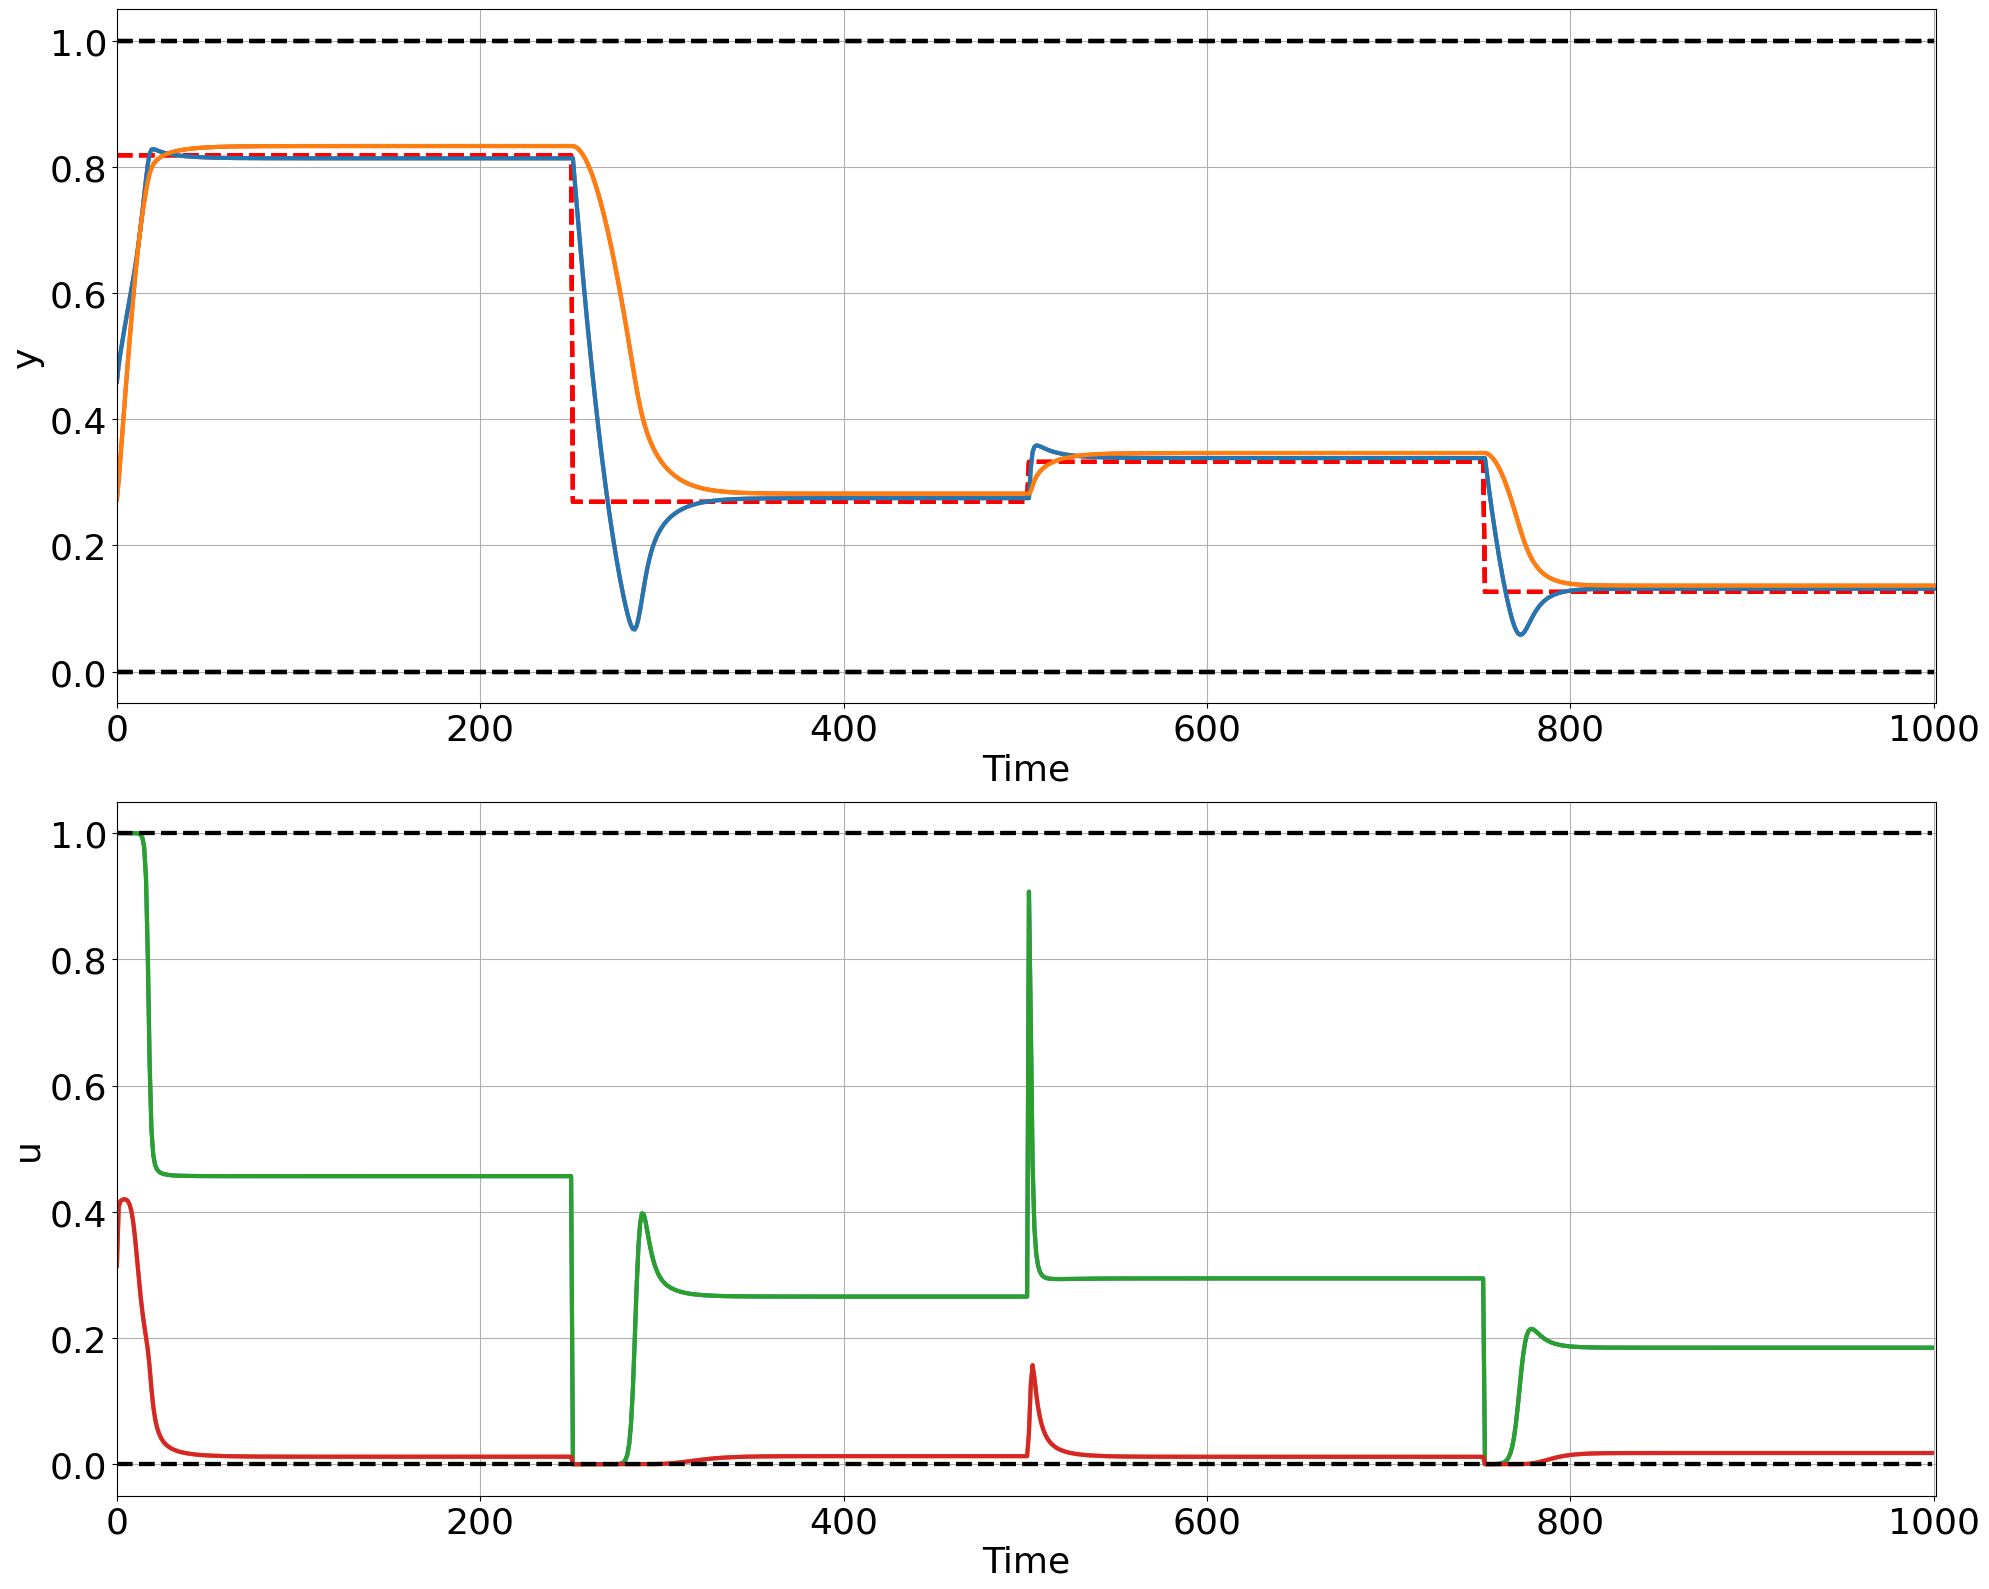

<Figure size 640x480 with 0 Axes>

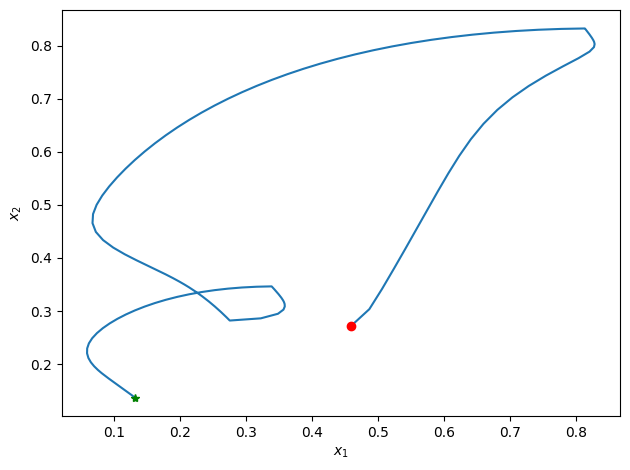

<Figure size 640x480 with 0 Axes>

In [110]:
cl_system.nsteps = nsteps
# perform closed-loop simulation
trajectories = cl_system(data)
# plot closed loop trajectories
pltCL(Y=trajectories['x'].detach().reshape(nsteps + 1, nx),
      R=trajectories['r'].detach().reshape(nsteps + 1, nref),
      U=trajectories['u'].detach().reshape(nsteps, nu),
      Umin=Umin, Umax=Umax, Ymin=Xmin, Ymax=Xmax,
      figname='cl.png')
# plot phase portrait
pltPhase(X=trajectories['x'].detach().reshape(nsteps + 1, nx),
         figname='phase.png')

## Conclusions

The trained DPC policy effectively address the reference-tracking problem without violating state or input constraints.